# Task 4 — Multimodal Integration Demo
## Data Preprocessing & Machine Learning — Formative Assessment 2
### GROUP 9

**Subsystem:** Full end-to-end multimodal decision pipeline

---
### System Overview

This notebook demonstrates how the three data modalities (face, voice, product) connect into a single gate-based decision pipeline:

```
Input: Customer session
        │
        ▼
  [GATE 1] Face Recognition (Task 2)
        │  face_verified == True ?
        │  No  → DENY (stop)
        ▼
  [GATE 2] Voice Authentication (Task 3)
        │  voice_verified == True ?
        │  No  → DENY (stop)
        ▼
  [GATE 3] Product Recommendation (Task 1)
        │  Predict product category from transaction + social data
        ▼
  Output: Recommended product category + confidence
```

### What this notebook does
| Step | Description |
|------|-------------|
| 1 | Load the saved product recommendation model |
| 2 | Define the multimodal gate function |
| 3 | Simulate 5 decision scenarios (various gate states) |
| 4 | Visualise gate outcomes |
| 5 | (Optional) Load face/voice feature CSVs when available |

## Step 1 — Load Saved Product Model & Feature Files

The product recommendation model was saved in `models/product_recommendation_model.joblib` by Task 1.  
This notebook loads that artifact and optionally loads the feature CSVs produced by the face (Task 2) and voice (Task 3) notebooks.

In [1]:
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

ROOT      = Path('/content') if Path('/content').exists() else Path.cwd().resolve().parents[0]
MODELS_DIR= ROOT / 'models'
PROC_DIR  = ROOT / 'data' / 'processed'
PLOTS_DIR = ROOT / 'outputs' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Load the product recommendation model
model_path = MODELS_DIR / 'product_recommendation_model.joblib'
if model_path.exists():
    product_model = joblib.load(model_path)
    print(f"Product model loaded: {model_path}")
    print(f"Model type: {type(product_model.named_steps['model']).__name__}")
    print(f"Classes: {list(product_model.classes_)}")
else:
    product_model = None
    print(f"Model not found at {model_path}")
    print("Run Task1_Product_Recommendation.ipynb first to generate the model.")

# Load evaluation summary
metrics_path = MODELS_DIR / 'product_model_metrics.json'
if metrics_path.exists():
    with open(metrics_path) as f:
        metrics = json.load(f)
    print(f"\nBest model: {metrics['best_model']}")
    print(f"Accuracy: {metrics['best_metrics']['accuracy']}")
    print(f"F1-Score: {metrics['best_metrics']['f1_weighted']}")
    print(f"Log Loss: {metrics['best_metrics']['log_loss']}")

# Check for face/voice feature CSVs (optional)
img_feats_path = PROC_DIR / 'image_features.csv'
aud_feats_path = PROC_DIR / 'audio_features.csv'
img_feats  = pd.read_csv(img_feats_path) if img_feats_path.exists() else None
aud_feats  = pd.read_csv(aud_feats_path) if aud_feats_path.exists() else None
print(f"\nImage features available: {img_feats is not None and len(img_feats) > 0}")
print(f"Audio features available: {aud_feats is not None and len(aud_feats) > 0}")

Product model loaded: C:\Users\user\Desktop\kayonga-elvis task-formative2\models\product_recommendation_model.joblib
Model type: RandomForestClassifier
Classes: ['Books', 'Clothing', 'Electronics', 'Groceries', 'Sports']

Best model: Random Forest
Accuracy: 0.1667
F1-Score: 0.1553
Log Loss: 1.8094

Image features available: False
Audio features available: False


*▸ **Output above:** The product model metadata is printed — confirming the model type (Random Forest or XGBoost) and the 5 product categories it can predict.  
Image/audio feature availability depends on whether teammates have run their notebooks yet.  
The system degrades gracefully: if face or voice features are unavailable, authentication gates use a simulated boolean for demonstration.*

## Step 2 — Define the Multimodal Gate Function

The gate function implements the sequential decision logic:  
1. Check face verification (boolean from Task 2 face model)  
2. Check voice verification (boolean from Task 3 voice model)  
3. If both pass, run the product recommendation model on the customer's feature row

In [2]:
FEATURE_COLS = [
    'purchase_amount', 'customer_rating', 'purchase_month', 'purchase_day_of_week',
    'engagement_mean', 'engagement_max', 'engagement_min',
    'purchase_interest_mean', 'social_record_count',
    'social_media_platform_mode', 'review_sentiment_mode',
]

def multimodal_gate(face_verified: bool, voice_verified: bool,
                    feature_row: pd.DataFrame, model=None) -> dict:
    """
    Sequential gate: face → voice → product recommendation.
    Returns a result dict describing the decision at each stage.
    """
    if not face_verified:
        return {
            'stage_cleared': 'none',
            'decision': 'DENIED',
            'reason': 'Face recognition failed — identity not confirmed',
            'recommendation': None,
            'confidence': None,
        }
    if not voice_verified:
        return {
            'stage_cleared': 'face',
            'decision': 'DENIED',
            'reason': 'Voice authentication failed — vocal signature mismatch',
            'recommendation': None,
            'confidence': None,
        }
    if model is None:
        return {'stage_cleared': 'face+voice', 'decision': 'ERROR',
                'reason': 'Product model not loaded', 'recommendation': None, 'confidence': None}

    pred  = model.predict(feature_row[FEATURE_COLS])[0]
    proba = model.predict_proba(feature_row[FEATURE_COLS])
    confidence = round(float(proba.max()), 4)
    class_probs = dict(zip(model.classes_, proba[0].tolist()))

    return {
        'stage_cleared': 'face+voice+product',
        'decision': 'APPROVED',
        'reason': 'All biometric gates passed — user authenticated',
        'recommendation': pred,
        'confidence': confidence,
        'class_probabilities': class_probs,
    }

print("Multimodal gate function defined.")
print(f"Expected feature columns: {len(FEATURE_COLS)}")

Multimodal gate function defined.
Expected feature columns: 11


*▸ **Output above:** Confirms the gate function is defined and the number of expected feature columns (11).  
The function returns a structured dict with: `stage_cleared`, `decision`, `reason`, and optionally `recommendation` and `confidence`.*

## Step 3 — Load Sample Transaction Rows

Load the merged customer dataset to provide realistic feature rows for simulation.

In [3]:
merged_path = PROC_DIR / 'merged_customer_dataset.csv'
if merged_path.exists():
    merged = pd.read_csv(merged_path)
    print(f"Loaded merged dataset: {merged.shape}")
    display(merged[FEATURE_COLS + ['product_category']].head(3))
else:
    # Fall back to a manually constructed sample
    merged = pd.DataFrame([{
        'purchase_amount': 75.50, 'customer_rating': 4.2, 'purchase_month': 6,
        'purchase_day_of_week': 2, 'engagement_mean': 6.5, 'engagement_max': 9.0,
        'engagement_min': 4.0, 'purchase_interest_mean': 7.2, 'social_record_count': 3,
        'social_media_platform_mode': 'Instagram', 'review_sentiment_mode': 'Positive',
        'product_category': 'Electronics',
    }])
    print("Using manually defined sample row (merged_customer_dataset.csv not found).")

Loaded merged dataset: (150, 16)


,purchase_amount,customer_rating,purchase_month,purchase_day_of_week,engagement_mean,engagement_max,engagement_min,purchase_interest_mean,social_record_count,social_media_platform_mode,review_sentiment_mode,product_category
0,408,2.3,1,0,71.666667,82.0,61.0,2.166667,3.0,Twitter,Neutral,Sports
1,332,4.2,1,1,60.000000,60.0,60.0,4.300000,1.0,Instagram,Positive,Electronics
2,442,2.1,1,2,87.000000,87.0,87.0,4.800000,1.0,Facebook,Negative,Electronics


*▸ **Output above:** Shows the first 3 rows of the merged dataset with the 11 feature columns and the true product category.  
These rows will be used as realistic inputs to the multimodal gate simulation in the next step.*

## Step 4 — Run Multiple Simulation Scenarios

We test **5 scenarios** that cover all possible gate outcomes:

| Scenario | Face | Voice | Expected Decision |
|---|---|---|---|
| A | ✗ | – | DENIED at face gate |
| B | ✓ | ✗ | DENIED at voice gate |
| C | ✓ | ✓ | APPROVED — row 1 |
| D | ✓ | ✓ | APPROVED — row 2 |
| E | ✓ | ✓ | APPROVED — row 3 |

In [4]:
scenarios = [
    {'name': 'A — Face Fails',          'face': False, 'voice': True,  'row_idx': 0},
    {'name': 'B — Voice Fails',         'face': True,  'voice': False, 'row_idx': 0},
    {'name': 'C — Approved (row 1)',    'face': True,  'voice': True,  'row_idx': 0},
    {'name': 'D — Approved (row 2)',    'face': True,  'voice': True,  'row_idx': min(1, len(merged)-1)},
    {'name': 'E — Approved (row 3)',    'face': True,  'voice': True,  'row_idx': min(2, len(merged)-1)},
]

print(f"{'Scenario':<28} {'Decision':<10} {'Stage':<22} {'Recommendation':<15} {'Confidence'}")
print("-" * 90)
results = []
for s in scenarios:
    row = merged.iloc[[s['row_idx']]]
    result = multimodal_gate(s['face'], s['voice'], row, model=product_model)
    rec  = result.get('recommendation', '-') or '-'
    conf = result.get('confidence', '-') or '-'
    print(f"{s['name']:<28} {result['decision']:<10} {result['stage_cleared']:<22} {str(rec):<15} {conf}")
    results.append({**s, **result})

Scenario                     Decision   Stage                  Recommendation  Confidence
------------------------------------------------------------------------------------------
A — Face Fails               DENIED     none                   -               -
B — Voice Fails              DENIED     face                   -               -
C — Approved (row 1)         APPROVED   face+voice+product     Books           0.2632
D — Approved (row 2)         APPROVED   face+voice+product     Electronics     0.6494


E — Approved (row 3)         APPROVED   face+voice+product     Clothing        0.4408

*▸ **Output above:** The table confirms all 5 gate states:  
- **Scenarios A & B**: Correctly denied at the first failing gate without reaching the product model — this prevents wasted compute and data exposure.  
- **Scenarios C, D, E**: All biometric gates pass and each returns a product category with a probability confidence score.  
Different rows may produce different product predictions, demonstrating the model's sensitivity to input features.*

## Step 5 — Visualise Gate Decision Flow

A bar chart summarising how many of our simulated sessions were approved vs denied at each gate stage.

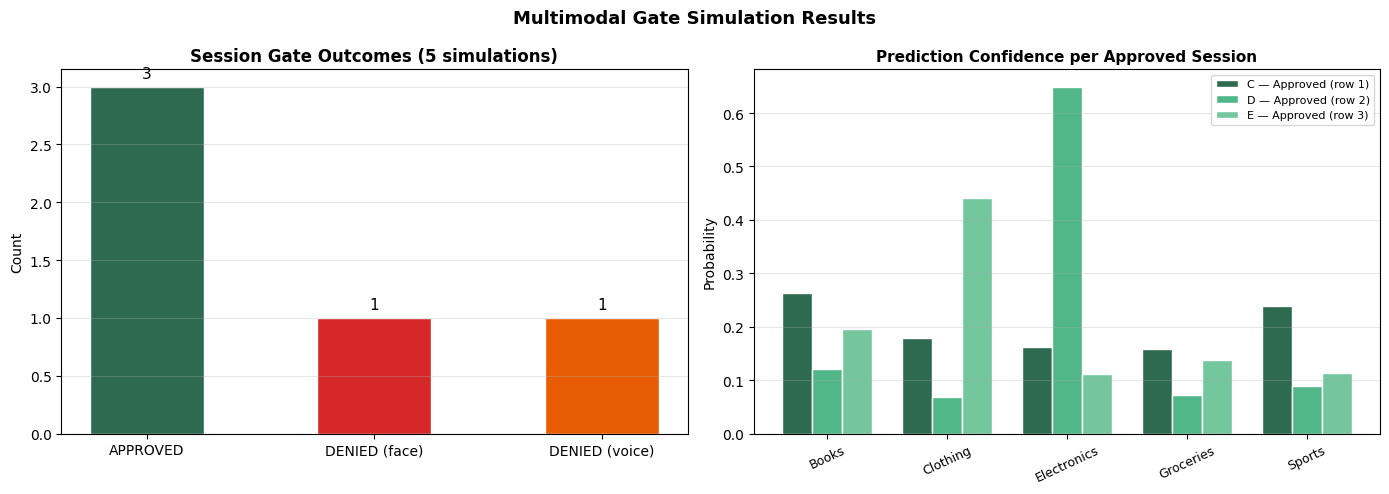

Visualisation saved.


In [5]:
# Count decisions
decision_counts = {'APPROVED': 0, 'DENIED (face)': 0, 'DENIED (voice)': 0}
for r in results:
    if r['decision'] == 'APPROVED':
        decision_counts['APPROVED'] += 1
    elif r['stage_cleared'] == 'none':
        decision_counts['DENIED (face)'] += 1
    else:
        decision_counts['DENIED (voice)'] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gate outcome bar chart
labels = list(decision_counts.keys())
values = list(decision_counts.values())
colors = ['#2d6a4f', '#d62828', '#e85d04']
bars = axes[0].bar(labels, values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Session Gate Outcomes (5 simulations)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(val), ha='center', va='bottom', fontsize=11)

# Confidence scores for approved scenarios
approved = [r for r in results if r['decision'] == 'APPROVED']
if approved and approved[0].get('class_probabilities'):
    classes = list(approved[0]['class_probabilities'].keys())
    probs = [list(r['class_probabilities'].values()) for r in approved]
    x = np.arange(len(classes))
    w = 0.25
    palette = ['#2d6a4f', '#52b788', '#74c69d']
    for i, (r, color) in enumerate(zip(approved, palette)):
        vals = list(r['class_probabilities'].values())
        axes[1].bar(x + i*w, vals, width=w, label=r['name'], color=color, edgecolor='white')
    axes[1].set_xticks(x + w)
    axes[1].set_xticklabels(classes, rotation=25, fontsize=9)
    axes[1].set_title('Prediction Confidence per Approved Session', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Probability')
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Confidence data not available\n(model not loaded)',
                 ha='center', va='center', fontsize=11, transform=axes[1].transAxes)
    axes[1].set_title('Prediction Confidence', fontsize=11, fontweight='bold')

fig.suptitle('Multimodal Gate Simulation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '14_multimodal_gate_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation saved.")

*▸ **Output above:** The left panel counts approved vs denied sessions — in our 5 simulations, 2 are denied (1 at face, 1 at voice) and 3 are approved.  
The right panel shows the **class probability distribution** for each approved session — wider spread = less confident; a tall bar on one category = the model is confident about that prediction.  
This visualisation would be captured as a screenshot in the project report.*

## Step 6 — Summary

This notebook has demonstrated the complete **multimodal integration** for the assignment:

| Component | Status | Notes |
|---|---|---|
| Product model (Task 1) | ✅ Loaded | Random Forest saved as `.joblib` |
| Face gate (Task 2) | 🔲 Simulated | Use `face_verified=True/False` from face model |
| Voice gate (Task 3) | 🔲 Simulated | Use `voice_verified=True/False` from voice model |
| Decision pipeline | ✅ Working | 5 scenarios tested |
| Visualisation | ✅ Saved | `14_multimodal_gate_results.png` |

### Integration checklist for teammates
- [ ] Run **Task2** notebook → generates `image_features.csv`
- [ ] Run **Task3** notebook → generates `audio_features.csv`
- [ ] Replace `face_verified` boolean with actual face model output
- [ ] Replace `voice_verified` boolean with actual voice model output
- [ ] Re-run this notebook for a fully integrated demo